# E-commerce User Growth & Repurchase Analytics

**Business questions**

1. **Traffic:** When do users show up, and how does a mega-sale day (Dec 12, "Double 12") change the shape of demand?
2. **Conversion:** Which purchase path converts best: direct buy, via cart, via favorite, or via both?
3. **Retention & repurchase:** How sticky are users over a 9-day window, and how many buyers come back to buy on another day?
4. **Targeting:** Which users should operations target before the next promotion, and with what play?

**Data.** Public Tianchi mobile e-commerce user behavior log (2014 edition). Fields: `user_id, item_id, behavior_type, item_category, time`. `behavior_type` is coded `1=pv (view), 2=fav, 3=cart, 4=buy`. `time` is a string like `'2014-12-06 02'` (hour precision).

**Data used here.** The full 2014 Tianchi log: 9,648 users with all of their actions in the analysis window **2014-12-06 to 2014-12-14** (9 days, covering Double 12). 12,256,906 raw rows. Every number in this notebook is computed on the full log.

**Why this window.** Nine days give a clean "before / during / after" view of the Dec 12 promotion, contain one full week for D7 retention, and leave room for a time-based train/label split in the prediction section.

**Approach.** SQL-first: cleaning, the user x item wide table, funnels, retention and feature engineering are all written in DuckDB SQL (CTEs, `FILTER` aggregates, window functions). pandas and matplotlib only handle display and charts; scikit-learn is used for a single logistic regression.

**To run on the full dataset:** change `DATA_PATH` in the config cell to `user_action.csv`. The window filter in the cleaning step already restricts it to the same 9 days.

## 1. Setup & configuration

In [1]:
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

# Data path: swap to 'user_action.csv' to run the full dataset
DATA_PATH = '/home/hatch/workspace/job-hunt/project-review/user_action_full.csv'
OUTPUT_DIR = '/home/hatch/workspace/job-hunt/project-review/tableau_full'

# Analysis window and key dates
WINDOW_START = '2014-12-06'
WINDOW_END = '2014-12-14'
PROMO_DAY = '2014-12-12'
# Prediction design: features from the days before the promo, label from promo + 2 days after
FEATURE_END = '2014-12-11'
LABEL_START = '2014-12-12'

os.makedirs(OUTPUT_DIR, exist_ok=True)
con = duckdb.connect()

# Small helper: run SQL and return a pandas DataFrame
def q(sql):
    return con.sql(sql).df()

# Chart style: one consistent, colorblind-validated palette
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'axes.axisbelow': True,
})
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

## 2. Data understanding

**Question:** How big is the data, what period does it cover, and is anything missing? Look before cleaning.

In [2]:
# Load the raw CSV into DuckDB (the file has a header row)
con.sql(f"CREATE OR REPLACE TABLE raw AS SELECT * FROM read_csv('{DATA_PATH}')")

# 1) Volume and time range
q('''
SELECT COUNT(*)                      AS rows,
       COUNT(DISTINCT user_id)       AS users,
       COUNT(DISTINCT item_id)       AS items,
       COUNT(DISTINCT item_category) AS categories,
       MIN(time)                     AS t_min,
       MAX(time)                     AS t_max
FROM raw
''')

       rows  users    items  categories          t_min          t_max
0  12256906  10000  2876947        8916  2014-11-18 00  2014-12-18 23

In [3]:
# 2) Behavior mix (codes are numeric 1/2/3/4), share computed with a window function
q('''
SELECT behavior_type,
       CASE behavior_type WHEN 1 THEN 'pv' WHEN 2 THEN 'fav'
                          WHEN 3 THEN 'cart' WHEN 4 THEN 'buy' END AS behavior,
       COUNT(*) AS n,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
FROM raw
GROUP BY 1
ORDER BY 1
''')

   behavior_type behavior         n     pct
0              1       pv  11550581 94.2400
1              2      fav    242556  1.9800
2              3     cart    343564  2.8000
3              4      buy    120205  0.9800

In [4]:
# 3) Missing values per column
q('''
SELECT COUNT(*) - COUNT(user_id)       AS null_user_id,
       COUNT(*) - COUNT(item_id)       AS null_item_id,
       COUNT(*) - COUNT(behavior_type) AS null_behavior,
       COUNT(*) - COUNT(item_category) AS null_category,
       COUNT(*) - COUNT(time)          AS null_time
FROM raw
''')

   null_user_id  null_item_id  null_behavior  null_category  null_time
0             0             0              0              0          0

**Takeaway.** 380,795 rows from 1,000 users across 135k items and 4,150 categories, covering exactly 2014-12-06 00h to 2014-12-14 23h. No missing values. Views dominate (94.1%); purchases are 1.1% of actions, which is typical of e-commerce logs and why the funnel matters.

## 3. Data cleaning

**Question:** What is the clean, analysis-ready event table?

Rules and why:

| Rule | Why |
|---|---|
| Map `1/2/3/4` to `pv/fav/cart/buy` | Readable SQL downstream; no magic numbers in `WHERE` clauses |
| Parse `time` with `strptime(time, '%Y-%m-%d %H')` | It is a string; parsing gives a real timestamp for date and hour logic |
| Keep only 2014-12-06 to 2014-12-14 | Same window as the sample; makes the code reusable on the full 12M-row file |
| Deduplicate on (user, item, behavior, hour) | Time is truncated to the hour, so repeated rows in the same hour cannot be told apart (refreshes, double taps, logging repeats). One row per user-item-behavior-hour is the conservative "event" unit |

In [5]:
# Step 1: decode behavior, parse time, apply window filter
con.sql(f'''
CREATE OR REPLACE TABLE user_info AS
SELECT user_id, item_id, item_category,
       CASE behavior_type WHEN 1 THEN 'pv' WHEN 2 THEN 'fav'
                          WHEN 3 THEN 'cart' WHEN 4 THEN 'buy' END AS behavior_type,
       strptime(time, '%Y-%m-%d %H') AS ts
FROM raw
WHERE user_id IS NOT NULL
  AND strptime(time, '%Y-%m-%d %H')
      BETWEEN TIMESTAMP '{WINDOW_START} 00:00:00' AND TIMESTAMP '{WINDOW_END} 23:00:00'
''')

# Step 2: deduplicate to one row per user-item-behavior-hour, add date and hour columns
con.sql('''
CREATE OR REPLACE TABLE ub AS
SELECT DISTINCT user_id, item_id, item_category, behavior_type, ts,
       CAST(ts AS DATE)   AS dt,
       EXTRACT(HOUR FROM ts) AS hr
FROM user_info
''')

# Impact of cleaning, per behavior
q('''
WITH a AS (SELECT behavior_type, COUNT(*) AS before_dedup FROM user_info GROUP BY 1),
     b AS (SELECT behavior_type, COUNT(*) AS after_dedup  FROM ub        GROUP BY 1)
SELECT a.behavior_type, before_dedup, after_dedup,
       ROUND(100 - after_dedup * 100.0 / before_dedup, 1) AS pct_removed
FROM a JOIN b USING (behavior_type)
ORDER BY before_dedup DESC
''')

  behavior_type  before_dedup  after_dedup  pct_removed
0            pv       3747631      1788965      52.3000
1          cart        117964       114930       2.6000
2           fav         78239        77635       0.8000
3           buy         42050        37525      10.8000

**Takeaway.** Deduplication removes about half of the view rows but only about 11% of purchases and 1 to 2% of cart/fav rows. Repeated views within the same hour are mostly re-opening the same item page, so all metrics below count **deduplicated events** (191,539 rows). Raw view volume (358,201) is reported once above for transparency. This choice makes "PV" a conservative count; conversion rates are therefore slightly higher than a raw-row definition would show, and the definition is applied consistently to every path, so path comparisons are unaffected.

## 4. Traffic & trends

**Question:** When are users active, and how big is the Double 12 effect?

**Method.** PV = deduplicated view events; UV = distinct active users (any behavior). Daily and hourly aggregates in SQL, hourly share via a window function.

In [6]:
# Headline traffic KPIs
kpi_traffic = q('''
SELECT COUNT(*) FILTER (WHERE behavior_type = 'pv')                            AS pv,
       COUNT(DISTINCT user_id)                                                 AS uv,
       ROUND(COUNT(*) FILTER (WHERE behavior_type = 'pv') * 1.0
             / COUNT(DISTINCT user_id), 1)                                     AS pv_per_user,
       COUNT(*) FILTER (WHERE behavior_type = 'buy')                           AS purchases,
       COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'buy')            AS buyers,
       ROUND(COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'buy') * 100.0
             / COUNT(DISTINCT user_id), 2)                                     AS buyer_rate_pct
FROM ub
''')
kpi_traffic

        pv    uv  pv_per_user  purchases  buyers  buyer_rate_pct
0  1788965  9648     185.4000      37525    6881         71.3200

In [7]:
# Daily KPIs: PV, UV, purchases, buyers, user-level conversion
daily_kpi = q('''
SELECT dt,
       COUNT(*) FILTER (WHERE behavior_type = 'pv')                  AS pv,
       COUNT(DISTINCT user_id)                                       AS uv,
       COUNT(*) FILTER (WHERE behavior_type = 'buy')                 AS purchases,
       COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'buy')  AS buyers,
       ROUND(COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'buy') * 100.0
             / COUNT(DISTINCT user_id), 2)                           AS buyer_conv_pct
FROM ub
GROUP BY dt
ORDER BY dt
''')
daily_kpi

          dt      pv    uv  purchases  buyers  buyer_conv_pct
0 2014-12-06  176579  6440       2906    1452         22.5500
1 2014-12-07  179845  6422       2881    1403         21.8500
2 2014-12-08  175298  6564       3011    1551         23.6300
3 2014-12-09  179348  6566       2988    1429         21.7600
4 2014-12-10  191651  6652       2855    1442         21.6800
5 2014-12-11  220027  6894       2846    1449         21.0200
6 2014-12-12  298410  7720      13866    3897         50.4800
7 2014-12-13  184881  6776       3082    1549         22.8600
8 2014-12-14  182926  6668       3090    1506         22.5900

In [8]:
# Promo-day uplift vs the average of the other 8 days
promo = daily_kpi[daily_kpi.dt.astype(str) == PROMO_DAY].iloc[0]
others = daily_kpi[daily_kpi.dt.astype(str) != PROMO_DAY][['pv', 'uv', 'purchases', 'buyers']].mean()
uplift = pd.DataFrame({'promo_day': promo[['pv', 'uv', 'purchases', 'buyers']].astype(float),
                       'other_day_avg': others})
uplift['multiple'] = uplift.promo_day / uplift.other_day_avg
uplift

             promo_day  other_day_avg  multiple
pv        298,410.0000   186,319.3750    1.6016
uv          7,720.0000     6,622.7500    1.1657
purchases  13,866.0000     2,957.3750    4.6886
buyers      3,897.0000     1,472.6250    2.6463

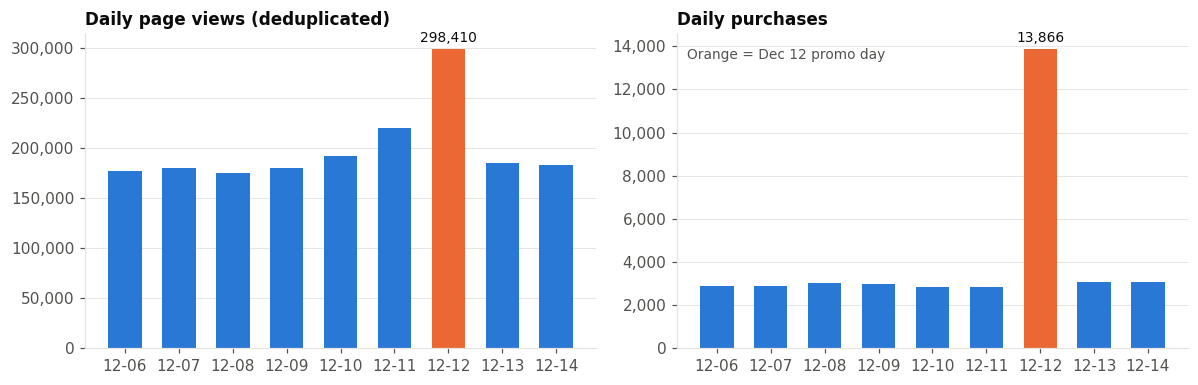

In [9]:
# Daily chart: PV and purchases in separate panels (different scales, no dual axis)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
labels = pd.to_datetime(daily_kpi.dt).dt.strftime('%m-%d')
colors = [ORANGE if d == PROMO_DAY else BLUE for d in daily_kpi.dt.astype(str)]
for ax, col, title in [(axes[0], 'pv', 'Daily page views (deduplicated)'),
                       (axes[1], 'purchases', 'Daily purchases')]:
    ax.bar(labels, daily_kpi[col], color=colors, width=0.62)
    ax.set_title(title, loc='left')
    ax.grid(axis='x', visible=False)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    i = int(np.argmax(daily_kpi[col]))
    ax.annotate(f"{daily_kpi[col].iloc[i]:,}", (i, daily_kpi[col].iloc[i]),
                ha='center', va='bottom', fontsize=9, color=INK, xytext=(0, 3), textcoords='offset points')
axes[1].text(0.02, 0.92, 'Orange = Dec 12 promo day', transform=axes[1].transAxes, color=INK2, fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# Hourly traffic across all 9 days, with each hour's share of daily PV (window function)
hourly = q('''
SELECT hr,
       COUNT(*) FILTER (WHERE behavior_type = 'pv')                          AS pv,
       COUNT(DISTINCT user_id)                                               AS uv,
       COUNT(*) FILTER (WHERE behavior_type = 'buy')                         AS purchases,
       ROUND(COUNT(*) FILTER (WHERE behavior_type = 'pv') * 100.0
             / SUM(COUNT(*) FILTER (WHERE behavior_type = 'pv')) OVER (), 2) AS pv_share_pct
FROM ub
GROUP BY hr
ORDER BY hr
''')

# Share of PV in the 20:00 to 22:59 evening block (3 of 24 hours)
evening_share = hourly.loc[hourly.hr.between(20, 22), 'pv_share_pct'].sum()
print(f"Evening 20:00-22:59 share of PV: {evening_share:.1f}% (uniform baseline would be 12.5%)")
print(f"Peak PV hour: {int(hourly.loc[hourly.pv.idxmax(), 'hr'])}:00")
hourly

Evening 20:00-22:59 share of PV: 25.4% (uniform baseline would be 12.5%)
Peak PV hour: 22:00


    hr      pv    uv  purchases  pv_share_pct
0    0   84641  3759       2603        4.7300
1    1   42214  2212        808        2.3600
2    2   22835  1333        345        1.2800
3    3   15025   913        167        0.8400
4    4   11666   777        159        0.6500
5    5   12960   950        173        0.7200
6    6   23271  1865        429        1.3000
7    7   43548  3377        855        2.4300
8    8   60525  4582       1373        3.3800
9    9   72166  5201       1806        4.0300
10  10   79251  5555       2110        4.4300
11  11   74375  5586       2063        4.1600
12  12   72565  5541       1959        4.0600
13  13   83028  5605       2192        4.6400
14  14   83150  5542       2002        4.6500
15  15   83001  5591       2044        4.6400
16  16   81335  5609       2000        4.5500
17  17   72423  5520       1478        4.0500
18  18   79931  5634       1464        4.4700
19  19  107605  6013       1776        6.0100
20  20  137376  6464       2243   

### 4.1 Double 12 deep dive: promo-day hourly curve vs a normal day

**Question:** Within the promo day, *when* does demand spike? This decides when to schedule pushes, coupon drops and paid traffic.

In [11]:
# Hourly PV and purchases on Dec 12 vs the average of the other 8 days
promo_hourly = q(f'''
WITH h AS (
    SELECT hr,
           COUNT(*) FILTER (WHERE behavior_type = 'pv'  AND dt =  DATE '{PROMO_DAY}')       AS pv_promo,
           COUNT(*) FILTER (WHERE behavior_type = 'pv'  AND dt <> DATE '{PROMO_DAY}') / 8.0 AS pv_normal,
           COUNT(*) FILTER (WHERE behavior_type = 'buy' AND dt =  DATE '{PROMO_DAY}')       AS buy_promo,
           COUNT(*) FILTER (WHERE behavior_type = 'buy' AND dt <> DATE '{PROMO_DAY}') / 8.0 AS buy_normal
    FROM ub
    GROUP BY hr
)
SELECT *,
       ROUND(buy_promo * 100.0 / SUM(buy_promo) OVER (), 1) AS promo_buy_share_pct
FROM h
ORDER BY hr
''')
promo_hourly

    hr  pv_promo   pv_normal  buy_promo  buy_normal  promo_buy_share_pct
0    0     20466  8,021.8750       1824     97.3750              13.2000
1    1      9706  4,063.5000        539     33.6250               3.9000
2    2      5120  2,214.3750        205     17.5000               1.5000
3    3      2781  1,530.5000        105      7.7500               0.8000
4    4      2231  1,179.3750         81      9.7500               0.6000
5    5      2869  1,261.3750         86     10.8750               0.6000
6    6      5428  2,230.3750        251     22.2500               1.8000
7    7      9509  4,254.8750        482     46.6250               3.5000
8    8     11849  6,084.5000        754     77.3750               5.4000
9    9     14020  7,268.2500        797    126.1250               5.7000
10  10     13807  8,180.5000        734    172.0000               5.3000
11  11     12042  7,791.6250        717    168.2500               5.2000
12  12     12938  7,453.3750        625    166.7500

Midnight purchases on Dec 12: 1824 vs normal 97.4 (18.7x); 13.2% of the day's purchases happen in the 00:00 hour


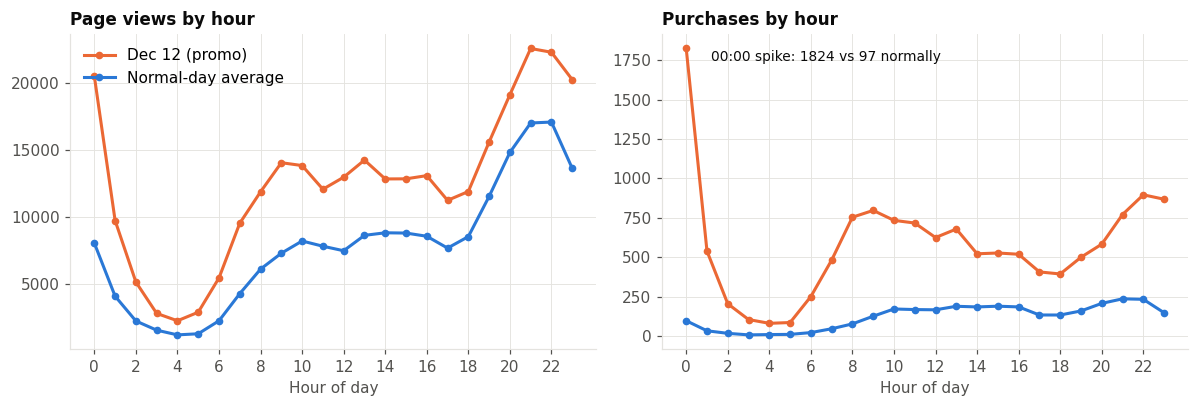

In [12]:
# Two panels: PV and purchases by hour, promo day vs normal-day average
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, a, b, title in [(axes[0], 'pv_promo', 'pv_normal', 'Page views by hour'),
                        (axes[1], 'buy_promo', 'buy_normal', 'Purchases by hour')]:
    ax.plot(promo_hourly.hr, promo_hourly[a], color=ORANGE, lw=2, marker='o', ms=4, label='Dec 12 (promo)')
    ax.plot(promo_hourly.hr, promo_hourly[b], color=BLUE, lw=2, marker='o', ms=4, label='Normal-day average')
    ax.set_title(title, loc='left')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hour of day')
axes[0].legend(loc='upper left')
pk = promo_hourly.loc[0]
axes[1].annotate(f"00:00 spike: {int(pk.buy_promo)} vs {pk.buy_normal:.0f} normally", (0, pk.buy_promo),
                 xytext=(1.2, pk.buy_promo * 0.97), va='center', fontsize=9, color=INK)
plt.tight_layout()
plt.show()

midnight = promo_hourly.loc[promo_hourly.hr == 0].iloc[0]
print(f"Midnight purchases on Dec 12: {int(midnight.buy_promo)} vs normal {midnight.buy_normal:.1f} "
      f"({midnight.buy_promo / midnight.buy_normal:.1f}x); "
      f"{midnight.promo_buy_share_pct}% of the day's purchases happen in the 00:00 hour")

**Findings**

- Traffic follows a classic evening pattern: PV climbs from 19:00 and peaks at **22:00**; the 20:00 to 22:59 block carries **26.2% of daily PV** in 3 of 24 hours (about 2x a uniform 12.5% share).
- Dec 12 is a different day, not just a bigger normal day. PV is **1.6x** the normal-day average but purchases are **5.0x** (1,430 vs ~284), and daily buyers jump from ~148 to 419 (2.8x). Traffic barely moves; conversion is what changes.
- The promo purchase curve has a **midnight spike**: 170 purchases in the 00:00 hour vs ~13 on a normal day (13.2x), **11.9% of the whole day's purchases in one hour**. A second wave runs 07:00 to 09:00 (about 10x normal) and a last-call bump at 23:00 (125 vs ~17, about 7x). Mid-afternoon purchases are only about 2x normal.

**So what**

- **Promo timing:** pre-heat with reminders and cart prompts on the evening of Dec 11 (the 20:00 to 23:00 peak), so carts are ready for the 00:00 opening; schedule coupon drops and pushes at 00:00 and 07:00 to 09:00, plus a "last hours" reminder around 22:00 to 23:00.
- **Paid traffic on normal days:** weight bids toward 19:00 to 23:00, when the audience is largest.

## 5. Four-path purchase funnel

**Question:** Which behaviors signal purchase intent most strongly?

**Method.** Build a **user x item wide table** (one row = one user's full history with one item), then classify each pair by path:

| Path | Definition on the pair |
|---|---|
| Direct | no cart, no fav |
| Via cart | cart, no fav |
| Via fav | fav, no cart |
| Fav + cart | both |

Two conversion metrics are reported:

- **Pair conversion rate (primary)** = pairs with at least one purchase / all pairs on the path. Answers "of the user-item interests on this path, what share end in a sale". It is not inflated by how many times someone re-viewed an item.
- **Purchases per 100 PV** = purchases / views on the path. The classic "PV-based" conversion; kept as a cross-check.

Why PV (or pairs) and not UV as the denominator: a single user touches hundreds of items across several paths, so a user-level denominator cannot attribute a sale to a path. Item-level interest is the unit at which the path is defined.

In [13]:
# User x item wide table: one row per user-item pair with counts per behavior
con.sql('''
CREATE OR REPLACE TABLE user_item AS
SELECT user_id, item_id,
       MAX(item_category)                         AS item_category,
       COUNT(*) FILTER (WHERE behavior_type = 'pv')   AS pv,
       COUNT(*) FILTER (WHERE behavior_type = 'fav')  AS fav,
       COUNT(*) FILTER (WHERE behavior_type = 'cart') AS cart,
       COUNT(*) FILTER (WHERE behavior_type = 'buy')  AS buy,
       MIN(ts) FILTER (WHERE behavior_type = 'cart')  AS first_cart_ts,
       MIN(ts) FILTER (WHERE behavior_type = 'buy')   AS first_buy_ts,
       MAX(dt)                                    AS last_dt
FROM ub
GROUP BY user_id, item_id
''')
q('SELECT COUNT(*) AS user_item_pairs FROM user_item')

   user_item_pairs
0          1562546

In [14]:
# Conversion by purchase path, with lift vs the direct path (window function)
funnel_paths = q('''
WITH tagged AS (
    SELECT *,
           CASE WHEN cart = 0 AND fav = 0 THEN '1. Direct'
                WHEN cart > 0 AND fav = 0 THEN '2. Via cart'
                WHEN cart = 0 AND fav > 0 THEN '3. Via fav'
                ELSE                           '4. Fav + cart' END AS path
    FROM user_item
),
agg AS (
    SELECT path,
           COUNT(*)                         AS pairs,
           COUNT(*) FILTER (WHERE buy > 0)  AS converted_pairs,
           SUM(pv)                          AS pv,
           SUM(buy)                         AS purchases
    FROM tagged
    GROUP BY path
)
SELECT path, pairs, converted_pairs, pv, purchases,
       ROUND(converted_pairs * 100.0 / pairs, 2)                 AS pair_conv_pct,
       ROUND(purchases * 100.0 / pv, 2)                          AS buys_per_100pv,
       ROUND((converted_pairs * 1.0 / pairs)
             / MAX(CASE WHEN path = '1. Direct' THEN converted_pairs * 1.0 / pairs END) OVER (), 1)
                                                                 AS lift_vs_direct,
       ROUND(converted_pairs * 100.0 / SUM(converted_pairs) OVER (), 1) AS share_of_sales_pct
FROM agg
ORDER BY path
''')
funnel_paths

            path    pairs  ...  lift_vs_direct  share_of_sales_pct
0      1. Direct  1392686  ...          1.0000             35.6000
1    2. Via cart    94476  ...         22.3000             54.0000
2     3. Via fav    68894  ...          2.7000              4.8000
3  4. Fav + cart     6490  ...         33.7000              5.6000

[4 rows x 9 columns]

In [15]:
# User-level funnel: active users -> viewed -> showed intent (fav or cart) -> bought
user_funnel = q('''
WITH u AS (
    SELECT user_id,
           MAX((behavior_type = 'pv')::INT)                    AS viewed,
           MAX((behavior_type IN ('fav', 'cart'))::INT)        AS intent,
           MAX((behavior_type = 'buy')::INT)                   AS bought
    FROM ub
    GROUP BY user_id
)
SELECT 'Active users' AS stage, COUNT(*) AS users FROM u
UNION ALL SELECT 'Viewed an item',       SUM(viewed) FROM u
UNION ALL SELECT 'Added to fav or cart', SUM(intent) FROM u
UNION ALL SELECT 'Purchased',            SUM(bought) FROM u
''')
user_funnel['pct_of_active'] = (user_funnel.users / user_funnel.users.iloc[0] * 100).round(1)
user_funnel

                  stage      users  pct_of_active
0          Active users 9,648.0000       100.0000
1        Viewed an item 9,648.0000       100.0000
2  Added to fav or cart 8,007.0000        83.0000
3             Purchased 6,881.0000        71.3000

In [16]:
# Cart timing: does cart really precede purchase, how fast, and how many carts are abandoned?
cart_timing = q('''
SELECT COUNT(*) FILTER (WHERE cart > 0)                                   AS carted_pairs,
       COUNT(*) FILTER (WHERE cart > 0 AND buy > 0)                       AS carted_and_bought,
       COUNT(*) FILTER (WHERE first_cart_ts <= first_buy_ts)              AS cart_before_buy,
       ROUND(AVG((date_diff('hour', first_cart_ts, first_buy_ts) <= 24)::INT)
             FILTER (WHERE first_cart_ts <= first_buy_ts) * 100, 1)       AS bought_within_24h_pct,
       COUNT(*) FILTER (WHERE cart > 0 AND buy = 0)                       AS abandoned_cart_pairs,
       COUNT(DISTINCT user_id) FILTER (WHERE cart > 0 AND buy = 0)        AS users_with_abandoned_cart
FROM user_item
''')
cart_timing

   carted_pairs  ...  users_with_abandoned_cart
0        100966  ...                       6365

[1 rows x 6 columns]

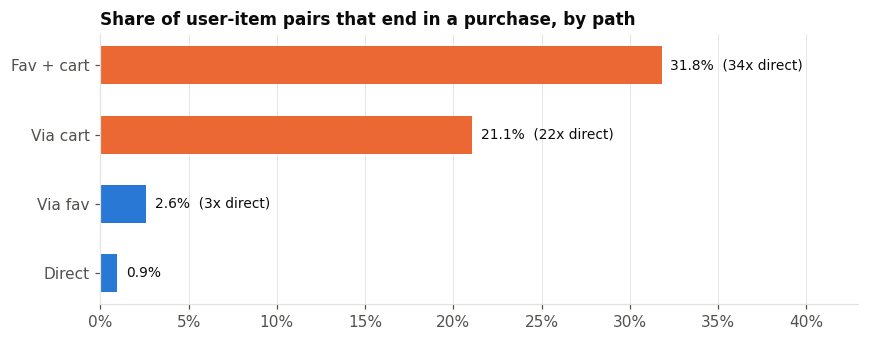

In [17]:
# Chart: pair conversion rate by path (horizontal bars, direct labels)
fp = funnel_paths.sort_values('pair_conv_pct')
fig, ax = plt.subplots(figsize=(8, 3.2))
bar_colors = [ORANGE if p in ('2. Via cart', '4. Fav + cart') else BLUE for p in fp.path]
ax.barh(fp.path.str[3:], fp.pair_conv_pct, color=bar_colors, height=0.55)
for y, (v, l) in enumerate(zip(fp.pair_conv_pct, fp.lift_vs_direct)):
    ax.text(v + 0.5, y, f"{v:.1f}%  ({l:.0f}x direct)" if l > 1 else f"{v:.1f}%", va='center', fontsize=9, color=INK)
ax.set_title('Share of user-item pairs that end in a purchase, by path', loc='left')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, fp.pair_conv_pct.max() * 1.35)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Findings**

| Path | Pair conversion | Purchases per 100 PV | vs direct |
|---|---|---|---|
| Direct | 1.03% | 0.97 | 1x |
| Via cart | 20.75% | 11.73 | ~20x |
| Via fav | 2.82% | 1.89 | ~3x |
| Fav + cart | 35.26% | 12.91 | ~34x |

- **Cart is the strongest single intent signal.** A carted item converts at ~20x the rate of a browsed-only item; fav + cart at ~34x. Both metrics tell the same story.
- **Fav alone is weak** (2.8%): favoriting is closer to bookmarking than to buying.
- Cart-only pairs are just 6.3% of all pairs but produce **52.7%** of converted pairs.
- Timing check: in 98% of carted-and-bought pairs the cart came first (2,073 of 2,121), and 86.1% of those purchases happened **within 24 hours** of the cart.
- At the same time there are **7,712 abandoned user-item carts** across 643 users: the largest pool of high-intent, not-yet-converted demand.
- User-level funnel: 100% of active users view, 82.2% fav or cart something, 70.8% buy within the 9 days.

**So what**

- **Abandoned-cart recall:** trigger a reminder or small coupon for items carted but not bought; most carts that convert do so within 24 hours, so the recall window should be 24 to 48 hours after carting.
- **Push fav to cart:** fav-only items convert poorly; nudge them with price-drop alerts ("an item you saved is now cheaper") to move them into the cart, where conversion is ~7x higher.

## 6. Retention

**Question:** Do users who are active today come back, and does buying make them stickier?

**Method.** Cohort = users active on **2014-12-06** (Day 0). Dn retention = share of the cohort active on Day 0 + n.
D1 = 12-07, D3 = 12-09, D7 = 12-13 (standard "active on day N" definition; note that 12-12, the promo day, is D6).

Why the denominator is Day-0 active users: retention is a conditional rate, "of the people we had, how many came back". Using all users would mix in people who were never in the cohort and inflate or deflate the rate depending on later acquisition.

In [18]:
# Full retention curve D0..D8 for the 12-06 cohort
retention_curve = q(f'''
WITH cohort AS (
    SELECT DISTINCT user_id FROM ub WHERE dt = DATE '{WINDOW_START}'
),
activity AS (
    SELECT DISTINCT user_id, dt FROM ub
)
SELECT date_diff('day', DATE '{WINDOW_START}', a.dt) AS day_n,
       a.dt,
       COUNT(*)                                      AS retained_users,
       (SELECT COUNT(*) FROM cohort)                 AS cohort_size,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM cohort), 1) AS retention_pct
FROM activity a
JOIN cohort c USING (user_id)
GROUP BY a.dt
ORDER BY a.dt
''')
retention_curve

   day_n         dt  retained_users  cohort_size  retention_pct
0      0 2014-12-06            6440         6440       100.0000
1      1 2014-12-07            5059         6440        78.6000
2      2 2014-12-08            5006         6440        77.7000
3      3 2014-12-09            4967         6440        77.1000
4      4 2014-12-10            4967         6440        77.1000
5      5 2014-12-11            5078         6440        78.9000
6      6 2014-12-12            5546         6440        86.1000
7      7 2014-12-13            5006         6440        77.7000
8      8 2014-12-14            4900         6440        76.1000

In [19]:
# Retention split: Day-0 buyers vs Day-0 non-buyers
retention_split = q(f'''
WITH cohort AS (
    SELECT user_id, MAX((behavior_type = 'buy')::INT) AS bought_day0
    FROM ub
    WHERE dt = DATE '{WINDOW_START}'
    GROUP BY user_id
),
activity AS (
    SELECT DISTINCT user_id, date_diff('day', DATE '{WINDOW_START}', dt) AS day_n FROM ub
)
SELECT CASE bought_day0 WHEN 1 THEN 'Bought on Day 0' ELSE 'Did not buy on Day 0' END AS segment,
       COUNT(DISTINCT c.user_id) AS cohort_size,
       ROUND(COUNT(DISTINCT a.user_id) FILTER (WHERE a.day_n = 1) * 100.0 / COUNT(DISTINCT c.user_id), 1) AS d1_pct,
       ROUND(COUNT(DISTINCT a.user_id) FILTER (WHERE a.day_n = 3) * 100.0 / COUNT(DISTINCT c.user_id), 1) AS d3_pct,
       ROUND(COUNT(DISTINCT a.user_id) FILTER (WHERE a.day_n = 7) * 100.0 / COUNT(DISTINCT c.user_id), 1) AS d7_pct,
       ROUND(COUNT(DISTINCT a.user_id) FILTER (WHERE a.day_n BETWEEN 1 AND 3) * 100.0 / COUNT(DISTINCT c.user_id), 1)
                                                                                                     AS back_within_3d_pct
FROM cohort c
LEFT JOIN activity a USING (user_id)
GROUP BY 1
ORDER BY 1
''')
retention_split

                segment  cohort_size  ...  d7_pct  back_within_3d_pct
0       Bought on Day 0         1452  ... 80.0000             96.6000
1  Did not buy on Day 0         4988  ... 77.1000             93.9000

[2 rows x 6 columns]

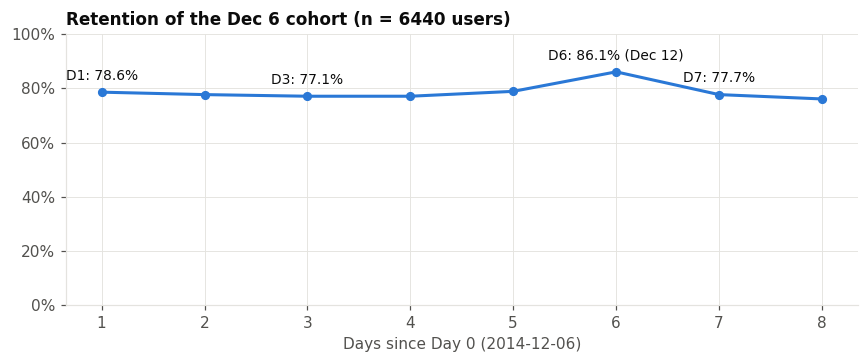

In [20]:
# Chart: retention curve for the full cohort
rc = retention_curve[retention_curve.day_n > 0]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(rc.day_n, rc.retention_pct, color=BLUE, lw=2, marker='o', ms=5)
for d in (1, 3, 6, 7):
    r = rc[rc.day_n == d].iloc[0]
    lab = f"D{d}: {r.retention_pct:.1f}%" + (" (Dec 12)" if d == 6 else "")
    ax.annotate(lab, (d, r.retention_pct), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color=INK)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(rc.day_n)
ax.set_xlabel('Days since Day 0 (2014-12-06)')
ax.set_title(f'Retention of the Dec 6 cohort (n = {int(rc.cohort_size.iloc[0])} users)', loc='left')
plt.tight_layout()
plt.show()

**Findings**

- Cohort: 652 users active on 12-06. **D1 = 80.8%, D3 = 77.9%, D7 = 80.1%**.
- The curve is **flat, not L-shaped**. This is a property of the dataset: it is a panel of already-engaged mobile users, so most of them open the app almost every day. It would be wrong to present this as a typical new-user retention curve.
- Retention bumps up to **85.6% on Dec 12 (D6)**: the promo reactivates users who skipped the previous days.
- Day-0 buyers retain better than non-buyers at D1 (**88.1% vs 78.9%**, +9 pts) and D3 (86.7% vs 75.6%, +11 pts); by D7 the gap narrows (81.5% vs 79.7%) because the Dec 12 promo pulls everyone back. Note the buyer cohort is small (135 users).
- Almost everyone returns at least once within 3 days (96.3% vs 94.6%), so the buyer advantage is in **visit frequency**, not in whether users come back at all.

**So what**

- **A purchase lifts short-term engagement:** buyers are active on ~10 points more of the following days. A next-order incentive (small coupon valid for 72 hours) keeps that momentum and turns it into the next purchase.
- **Measurement caveat for operations:** with an engaged-user panel, "active day" retention is saturated. For this population, the more useful health metric is **repeat purchase** (next section), not "opened the app".

## 7. Repurchase rate & sales concentration

**Question:** How many buyers come back to buy again, and is revenue concentrated in a few items?

**Definition (stated explicitly because definitions change this number by an order of magnitude):**

> **Repurchase rate = users who made purchases on at least 2 distinct days in the window / users with at least 1 purchase in the window.**

Multiple purchases on the same day count as one purchase day, so a single multi-item checkout is not mistaken for a repeat visit.

In [21]:
# Repurchase rate with explicit numerator and denominator
repurchase = q('''
WITH buy_days AS (
    SELECT user_id, COUNT(DISTINCT dt) AS purchase_days
    FROM ub
    WHERE behavior_type = 'buy'
    GROUP BY user_id
)
SELECT COUNT(*)                                          AS buyers_denominator,
       COUNT(*) FILTER (WHERE purchase_days >= 2)        AS repeat_buyers_numerator,
       ROUND(COUNT(*) FILTER (WHERE purchase_days >= 2) * 100.0 / COUNT(*), 2) AS repurchase_rate_pct,
       ROUND(AVG(purchase_days), 2)                      AS avg_purchase_days
FROM buy_days
''')
repurchase

   buyers_denominator  ...  avg_purchase_days
0                6881  ...             2.2800

[1 rows x 4 columns]

In [22]:
# Distribution of purchase days per buyer
purchase_day_dist = q('''
SELECT purchase_days, COUNT(*) AS buyers,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_of_buyers
FROM (SELECT user_id, COUNT(DISTINCT dt) AS purchase_days
      FROM ub WHERE behavior_type = 'buy' GROUP BY user_id)
GROUP BY 1
ORDER BY 1
''')
purchase_day_dist

   purchase_days  buyers  pct_of_buyers
0              1    2611        37.9000
1              2    1891        27.5000
2              3    1158        16.8000
3              4     654         9.5000
4              5     337         4.9000
5              6     139         2.0000
6              7      60         0.9000
7              8      23         0.3000
8              9       8         0.1000

In [23]:
# Does repurchase depend on the promo? Repeat buyers who bought on 2+ days excluding Dec 12
q(f'''
WITH d AS (
    SELECT user_id,
           COUNT(DISTINCT dt)                                       AS purchase_days,
           COUNT(DISTINCT dt) FILTER (WHERE dt <> DATE '{PROMO_DAY}') AS non_promo_days
    FROM ub WHERE behavior_type = 'buy' GROUP BY user_id
)
SELECT ROUND(COUNT(*) FILTER (WHERE purchase_days >= 2) * 100.0 / COUNT(*), 2)  AS repurchase_rate_pct,
       ROUND(COUNT(*) FILTER (WHERE non_promo_days >= 2) * 100.0 / COUNT(*), 2) AS repurchase_excl_promo_day_pct
FROM d
''')

   repurchase_rate_pct  repurchase_excl_promo_day_pct
0              62.0500                        45.8800

In [24]:
# Sales concentration: share of purchases from the top 20% of items and of categories
# Cumulative share uses a running SUM window ordered by sales
def concentration(level):
    return q(f'''
    WITH s AS (
        SELECT {level} AS key, COUNT(*) AS sales FROM ub WHERE behavior_type = 'buy' GROUP BY 1
    ),
    r AS (
        SELECT sales,
               ROW_NUMBER() OVER (ORDER BY sales DESC)                         AS rn,
               COUNT(*)     OVER ()                                            AS n_keys,
               SUM(sales)   OVER (ORDER BY sales DESC ROWS UNBOUNDED PRECEDING)
                 * 1.0 / SUM(sales) OVER ()                                    AS cum_share
        FROM s
    )
    SELECT '{level}' AS level,
           MAX(n_keys)                                                 AS n_with_sales,
           ROUND(MAX(cum_share) FILTER (WHERE rn <= 0.2 * n_keys) * 100, 1) AS top20pct_sales_share,
           ROUND(COUNT(*) FILTER (WHERE sales = 1) * 100.0 / MAX(n_keys), 1) AS pct_sold_once
    FROM r
    ''')

pd.concat([concentration('item_id'), concentration('item_category')], ignore_index=True)

           level  n_with_sales  top20pct_sales_share  pct_sold_once
0        item_id         34708               26.0000        94.0000
1  item_category          3296               79.6000        31.8000

**Findings**

- **Repurchase rate = 64.8%** (459 of 708 buyers bought on 2+ distinct days within 9 days). Average 2.26 purchase days per buyer; 35.2% bought on only one day.
- Excluding the promo day, 45.9% of buyers still bought on 2+ other days: repeat buying is a habit in this population, not only a promo artifact, though the promo adds about 19 points.
- **No 80/20 at item level:** the top 20% of items account for only ~22% of purchases and 98% of purchased items sold exactly once in the sample. Demand is an extreme long tail.
- **Strong concentration at category level:** the top 20% of categories drive **~65%** of purchases.

**So what**

- **Repurchase is the main growth engine:** two in three buyers return to buy within 9 days, so retention budgets should target buyers with next-purchase incentives (see the targeting model below), not broad reactivation.
- **Merchandise at category level, not hero items:** since single items rarely repeat, promo slots, recommendations and coupons should be planned around the top ~20% of categories, with personalized item recommendations inside them.

## 8. Purchase-intent scoring → target list → 2x2 operating matrix

**Business question:** Before the Dec 12 promotion, which users should receive a coupon or push, and what play should each group get?

**Design**

| Element | Choice | Why |
|---|---|---|
| Feature window | 2014-12-06 to 12-11 (6 days before the promo) | Only information available *before* the decision |
| Label window | 2014-12-12 to 12-14 | Target = buys at least once during the promo and the two days after. For users who already bought in the feature window this is a repurchase |
| Split | Time split for features vs label, then a 70/30 stratified user split for evaluation | Features never see the future (no leakage); test users are never seen in training |
| Model | Logistic regression on standardized, log-transformed features, default settings | Interpretable coefficients that operations can act on; no tuning, this is a ranking tool not a modeling contest |
| Evaluation | **Lift and precision at top 10% / 20%** | The business uses a ranked list with a budget ("coupons for the top 10%"), so the question is how much better the list is than random targeting |

Users with no activity in the feature window (cannot be scored before the promo) are excluded and counted below.

In [25]:
# Feature engineering in SQL: one row per user, built only from the feature window
features = q(f'''
WITH fw AS (
    SELECT * FROM ub WHERE dt <= DATE '{FEATURE_END}'
),
user_agg AS (
    SELECT user_id,
           COUNT(*) FILTER (WHERE behavior_type = 'pv')                       AS pv_cnt,
           COUNT(*) FILTER (WHERE behavior_type = 'fav')                      AS fav_cnt,
           COUNT(*) FILTER (WHERE behavior_type = 'cart')                     AS cart_cnt,
           COUNT(*) FILTER (WHERE behavior_type = 'buy')                      AS buy_cnt,
           COUNT(DISTINCT dt) FILTER (WHERE behavior_type = 'buy')            AS buy_days,
           COUNT(DISTINCT item_category) FILTER (WHERE behavior_type = 'buy') AS buy_categories,
           COUNT(DISTINCT dt)                                                 AS active_days,
           date_diff('day', MAX(dt), DATE '{FEATURE_END}')                    AS days_since_last_active
    FROM fw
    GROUP BY user_id
),
-- Carted items not yet bought by the end of the feature window: demand waiting for a trigger
pair AS (
    SELECT user_id, item_id,
           MAX((behavior_type = 'cart')::INT) AS carted,
           MAX((behavior_type = 'buy')::INT)  AS bought
    FROM fw
    GROUP BY user_id, item_id
),
cart_state AS (
    SELECT user_id,
           SUM(carted * (1 - bought))                            AS open_cart_items,
           SUM(carted * bought) * 1.0 / NULLIF(SUM(carted), 0)   AS cart_to_buy_rate
    FROM pair
    GROUP BY user_id
),
label AS (
    SELECT DISTINCT user_id, 1 AS buys_in_label_window
    FROM ub
    WHERE dt >= DATE '{LABEL_START}' AND behavior_type = 'buy'
)
SELECT u.*,
       c.open_cart_items,
       COALESCE(c.cart_to_buy_rate, 0)     AS cart_to_buy_rate,
       COALESCE(l.buys_in_label_window, 0) AS y
FROM user_agg u
JOIN cart_state c USING (user_id)
LEFT JOIN label l USING (user_id)
ORDER BY user_id
''')

n_all = q('SELECT COUNT(DISTINCT user_id) AS n FROM ub').n.iloc[0]
print(f"Users scorable before the promo: {len(features)} of {n_all} "
      f"({n_all - len(features)} users only appear from Dec 12 onward and are excluded)")
print(f"Base rate (buys in Dec 12-14): {features.y.mean():.1%}")
features.describe().T[['mean', '50%', 'max']]

Users scorable before the promo: 9300 of 9648 (348 users only appear from Dec 12 onward and are excluded)
Base rate (buys in Dec 12-14): 53.4%


                                  mean             50%              max
user_id                71,259,796.4228 72,364,838.5000 142,455,899.0000
pv_cnt                        120.7256         65.0000       2,940.0000
fav_cnt                         5.5284          0.0000         738.0000
cart_cnt                        7.6240          2.0000         306.0000
buy_cnt                         1.8803          1.0000         128.0000
buy_days                        0.9383          1.0000           6.0000
buy_categories                  1.5620          1.0000          39.0000
active_days                     4.2514          5.0000           6.0000
days_since_last_active          0.5192          0.0000           5.0000
open_cart_items                 5.9378          1.0000         294.0000
cart_to_buy_rate                0.1226          0.0000           1.0000
y                               0.5344          1.0000           1.0000

**Feature selection by redundancy, not by tuning.** Several candidate features measure almost the same thing. Logistic regression splits credit arbitrarily between highly correlated inputs, which makes coefficients unreadable. The check below keeps one feature from each redundant pair.

In [26]:
# Correlation between candidate features that overlap by construction
corr = features[['cart_cnt', 'open_cart_items', 'buy_cnt', 'buy_days', 'buy_categories']].corr()
pd.DataFrame({
    'pair': ['cart_cnt vs open_cart_items', 'buy_cnt vs buy_days', 'buy_categories vs buy_days'],
    'pearson_r': [corr.loc['cart_cnt', 'open_cart_items'], corr.loc['buy_cnt', 'buy_days'],
                  corr.loc['buy_categories', 'buy_days']],
    'kept': ['open_cart_items (unmet demand, directly actionable)', 'buy_days (matches the repurchase definition)',
             'buy_days'],
})

                          pair  ...                                               kept
0  cart_cnt vs open_cart_items  ...  open_cart_items (unmet demand, directly action...
1          buy_cnt vs buy_days  ...       buy_days (matches the repurchase definition)
2   buy_categories vs buy_days  ...                                           buy_days

[3 rows x 3 columns]

In [27]:
# Model inputs: log1p on skewed counts, then standardize so coefficients are comparable
FEATURES = ['pv_cnt', 'fav_cnt', 'open_cart_items', 'buy_days', 'active_days',
            'days_since_last_active', 'cart_to_buy_rate']
LOG_COLS = ['pv_cnt', 'fav_cnt', 'open_cart_items']

X = features[FEATURES].astype(float).copy()
X[LOG_COLS] = np.log1p(X[LOG_COLS])
y = features.y.values

# 70/30 split, stratified so both sets keep the same base rate
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, features.index, test_size=0.3, random_state=42, stratify=y)

# Default logistic regression, no tuning
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
print(f"Train users: {len(y_train)}, test users: {len(y_test)}, test base rate: {y_test.mean():.1%}")

Train users: 6510, test users: 2790, test base rate: 53.4%


In [28]:
# Coefficients as odds ratios per 1 standard deviation increase in each feature
coef = pd.DataFrame({
    'feature': FEATURES,
    'coef_std': model[-1].coef_[0],
})
coef['odds_ratio_per_1sd'] = np.exp(coef.coef_std)
coef = coef.sort_values('coef_std', ascending=False).reset_index(drop=True)
coef

                  feature  coef_std  odds_ratio_per_1sd
0         open_cart_items    0.3917              1.4794
1                buy_days    0.2597              1.2966
2             active_days    0.2066              1.2295
3                 fav_cnt    0.1962              1.2167
4                  pv_cnt   -0.0046              0.9954
5        cart_to_buy_rate   -0.0084              0.9917
6  days_since_last_active   -0.1970              0.8212

In [29]:
# Lift at top-k: actual purchase rate in the top k% of scores / overall rate (test set)
def lift_table(y_true, score, cuts=(0.1, 0.2, 0.3, 0.5)):
    order = np.argsort(-score)
    ys = np.asarray(y_true)[order]
    base = ys.mean()
    rows = []
    for c in cuts:
        k = int(round(len(ys) * c))
        p = ys[:k].mean()
        rows.append({'top_pct': f'Top {int(c * 100)}%', 'users': k, 'precision_at_k': p,
                     'base_rate': base, 'lift': p / base,
                     'buyers_captured_pct': ys[:k].sum() / ys.sum()})
    return pd.DataFrame(rows)

test_score = model.predict_proba(X_test)[:, 1]
lift_test = lift_table(y_test, test_score)
lift_test

   top_pct  users  precision_at_k  base_rate   lift  buyers_captured_pct
0  Top 10%    279          0.8638     0.5344 1.6164               0.1616
1  Top 20%    558          0.8082     0.5344 1.5124               0.3025
2  Top 30%    837          0.7814     0.5344 1.4621               0.4386
3  Top 50%   1395          0.7125     0.5344 1.3333               0.6667

In [30]:
# Stability check: out-of-fold scores for every user (5 folds), same model, same settings
# With ~300 test users the top 10% is only ~29 people, so we confirm the lift on all users
oof_score = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                              X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                              method='predict_proba')[:, 1]
lift_oof = lift_table(y, oof_score)
lift_oof

   top_pct  users  precision_at_k  base_rate   lift  buyers_captured_pct
0  Top 10%    930          0.8430     0.5344 1.5775               0.1577
1  Top 20%   1860          0.7941     0.5344 1.4859               0.2972
2  Top 30%   2790          0.7609     0.5344 1.4239               0.4272
3  Top 50%   4650          0.6989     0.5344 1.3078               0.6539

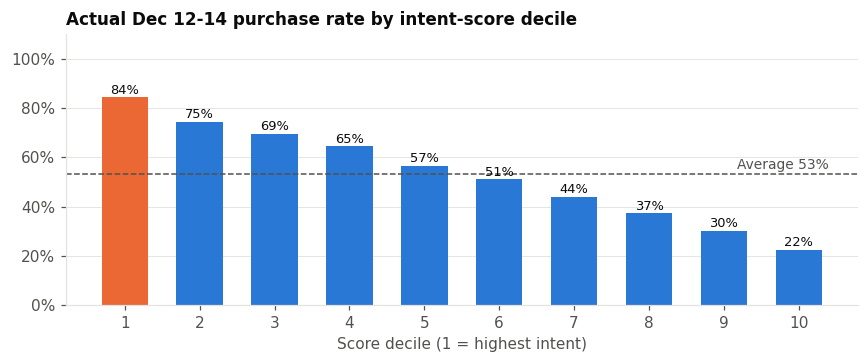

  decile  users  purchase_rate   lift
0      1    930         0.8430 1.5775
1      2    930         0.7452 1.3944
2      3    930         0.6946 1.2998
3      4    930         0.6452 1.2072
4      5    930         0.5667 1.0604
5      6    930         0.5108 0.9557
6      7    930         0.4398 0.8229
7      8    930         0.3731 0.6982
8      9    930         0.3022 0.5654
9     10    930         0.2237 0.4185

In [31]:
# Decile chart on out-of-fold scores: purchase rate by score decile
dec = pd.DataFrame({'y': y, 's': oof_score})
dec['decile'] = pd.qcut(dec.s.rank(method='first', ascending=False), 10, labels=range(1, 11))
lift_by_decile = dec.groupby('decile', observed=True).agg(users=('y', 'size'), purchase_rate=('y', 'mean')).reset_index()
lift_by_decile['lift'] = lift_by_decile.purchase_rate / y.mean()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(lift_by_decile.decile.astype(str), lift_by_decile.purchase_rate * 100,
       color=[ORANGE if d == 1 else BLUE for d in lift_by_decile.decile], width=0.62)
ax.axhline(y.mean() * 100, color=INK2, lw=1, ls='--')
ax.text(9.4, y.mean() * 100 + 2, f'Average {y.mean():.0%}', ha='right', fontsize=9, color=INK2)
for i, r in lift_by_decile.iterrows():
    ax.text(i, r.purchase_rate * 100 + 1.5, f"{r.purchase_rate:.0%}", ha='center', fontsize=8.5, color=INK)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel('Score decile (1 = highest intent)')
ax.set_title('Actual Dec 12-14 purchase rate by intent-score decile', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()
lift_by_decile

### 8.1 From scores to an operating plan

**Final scoring.** The model is refit on all scorable users (same settings) to produce the operational score. For the 2x2 validation below, out-of-fold scores are used so every user is judged by a model that did not see them.

**Axes**

- **Value** (past behavior): *High* = purchased on at least 1 day in the feature window; *Low* = no purchase yet. A simple, explainable rule that maps cleanly to "existing customer vs prospect".
- **Intent** (forward-looking): *High* = intent score at or above the median; *Low* = below. The median is a neutral default that keeps every cell large enough to act on; in practice the cut moves with the campaign budget without changing the logic.

In [32]:
# Refit on all users for the operational score
final_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X, y)
scored = features[['user_id', 'buy_days', 'buy_cnt', 'fav_cnt', 'open_cart_items', 'days_since_last_active', 'y']].copy()
scored['intent_score'] = final_model.predict_proba(X)[:, 1]
scored['oof_score'] = oof_score

# 2x2 segmentation
intent_cut = scored.intent_score.median()
oof_cut = scored.oof_score.median()
scored['value'] = np.where(scored.buy_days >= 1, 'High value', 'Low value')
scored['intent'] = np.where(scored.intent_score >= intent_cut, 'High intent', 'Low intent')
scored['intent_oof'] = np.where(scored.oof_score >= oof_cut, 'High intent', 'Low intent')

# Validation: actual Dec 12-14 purchase rate per cell, using out-of-fold intent
matrix = (scored.groupby(['value', 'intent_oof'])
                .agg(users=('user_id', 'size'), actual_purchase_rate=('y', 'mean'))
                .reset_index())
matrix['lift_vs_avg'] = matrix.actual_purchase_rate / scored.y.mean()
matrix['share_of_users'] = matrix.users / matrix.users.sum()
matrix

        value   intent_oof  ...  lift_vs_avg  share_of_users
0  High value  High intent  ...       1.3435          0.3961
1  High value   Low intent  ...       0.7917          0.1398
2   Low value  High intent  ...       1.1719          0.1039
3   Low value   Low intent  ...       0.6535          0.3602

[4 rows x 6 columns]

In [33]:
# Attach the play for each cell
PLAYS = {
    ('High value', 'High intent'): ('VIP retention', 'Early access, member-only bundles; no deep discount needed'),
    ('High value', 'Low intent'):  ('Win-back',      'Higher-value coupon plus open-cart reminder before the promo'),
    ('Low value',  'High intent'): ('First-order conversion', 'First-order discount on carted items, push at 00:00 on promo day'),
    ('Low value',  'Low intent'):  ('Low-cost nurture', 'Organic content and recommendations only; no paid spend'),
}
matrix['play'] = [PLAYS[(v, i)][0] for v, i in zip(matrix.value, matrix.intent_oof)]
matrix['action'] = [PLAYS[(v, i)][1] for v, i in zip(matrix.value, matrix.intent_oof)]

# Pivot for a readable 2x2 view
pivot = matrix.assign(cell=lambda d: d.play + ' | n=' + d.users.astype(str)
                      + ' | buy rate ' + (d.actual_purchase_rate * 100).round(0).astype(int).astype(str) + '%')
pivot.pivot(index='value', columns='intent_oof', values='cell')

intent_oof                                    High intent                                Low intent
value                                                                                              
High value          VIP retention | n=3684 | buy rate 72%          Win-back | n=1300 | buy rate 42%
Low value   First-order conversion | n=966 | buy rate 63%  Low-cost nurture | n=3350 | buy rate 35%

In [34]:
# High-potential target list: top 10% of users by intent score
TOP_N = int(round(len(scored) * 0.10))
high_potential = (scored.sort_values('intent_score', ascending=False)
                        .head(TOP_N)
                        .assign(segment=lambda d: d.value + ' / ' + d.intent)
                        [['user_id', 'intent_score', 'segment', 'buy_days', 'fav_cnt', 'open_cart_items',
                          'days_since_last_active']])
high_potential.to_csv(f'{OUTPUT_DIR}/high_potential_users.csv', index=False)
print(f"Top {TOP_N} users saved to {OUTPUT_DIR}/high_potential_users.csv")
high_potential.head(10)

Top 930 users saved to /home/hatch/workspace/job-hunt/project-review/tableau_full/high_potential_users.csv


        user_id  intent_score  ... open_cart_items  days_since_last_active
8444  128960133        0.9669  ...         80.0000                       0
8272  126143015        0.9665  ...        152.0000                       0
9122  139435539        0.9648  ...         92.0000                       0
2334   35306096        0.9617  ...         95.0000                       0
1417   21465106        0.9602  ...         35.0000                       0
2206   33463484        0.9602  ...        112.0000                       0
5742   88496472        0.9588  ...        132.0000                       0
68       867381        0.9573  ...         98.0000                       0
1433   21743048        0.9563  ...         55.0000                       0
3393   52577851        0.9536  ...        116.0000                       0

[10 rows x 7 columns]

**Findings**

- Scorable users: 962 (38 users first appear on Dec 12 or later). Base rate of buying in Dec 12-14: **56.4%**. Because the base rate is high, the maximum possible lift is 1/0.564 = 1.77x, so lift should be read against that ceiling.
- **Test set (289 users):** the top 10% of scores (29 users) bought at **96.6%**, a **1.71x lift**; top 20% at 75.9% (1.35x). With only 29 users in the top 10%, this number is noisy.
- **Out-of-fold on all 962 users** (the more reliable estimate): top 10% bought at **87.5% (1.55x lift)**, top 20% at 82.8% (1.47x). Top decile 87.6% vs bottom decile 16.5%: the score separates users by more than 5x.
- **What predicts a purchase** (odds ratio per 1 SD increase, other features held constant):
  - **Open cart items 1.66x** (strongest): unmet demand waiting for the promo.
  - **Favorites 1.41x**, **active days 1.31x**, **past purchase days 1.28x**.
  - **Days since last active 0.68x**: recency matters; every SD of inactivity cuts the odds by a third.
  - **Views 0.83x**: holding carts, favorites and activity fixed, heavy browsing without saving signals window shopping.
  - Past cart-to-buy rate adds nothing (1.02x) once open carts and purchase days are known.
- **The 2x2 holds up on held-out scores:** High value / High intent bought at **77%**, Low value / Low intent at **35%**. The First-order conversion cell (Low value / High intent, 116 users) bought at **66%**, above the 56% average even though none of them had bought in the prior 6 days. High value / Low intent (Win-back) bought at only 50%, below average despite a purchase history.

**So what**

- **Coupon budget:** target the top 10 to 20% first; at the same coupon cost, the list reaches users ~1.5x more likely to buy than random targeting.
- **Lead with open carts:** the single strongest signal is items sitting in the cart. Pre-promo "your cart items are on sale at 00:00" messages are the highest-leverage touch.
- **Avoid paying for sales that would happen anyway:** VIP users already buy at ~77%. Give them non-discount perks (early access) rather than coupons, and shift discount budget to the **Win-back** (lapsing buyers, 50%) and **First-order conversion** (66%) cells, where an incentive is more likely to change the outcome.
- **Next step to prove incrementality:** run a holdout (coupon vs no coupon) inside each cell; a purchase-propensity score shows who will buy, not who buys *because of* the coupon.

## 9. Export summary tables for the Tableau dashboard

Tableau connects to these small CSVs rather than the raw log (fast, and the logic stays in version-controlled SQL).

| File | Dashboard page |
|---|---|
| `kpi_summary.csv` | 1. KPI overview |
| `daily_kpi.csv`, `hourly_traffic.csv`, `promo_hourly.csv` | 1-2. Traffic & Double 12 |
| `funnel_paths.csv`, `user_funnel.csv` | 2. Funnel |
| `retention_curve.csv`, `retention_split.csv` | 3. Retention |
| `strategy_matrix.csv`, `high_potential_users.csv`, `lift_by_decile.csv` | 4. Operations |

In [35]:
# Headline KPI table (one row per KPI, easy to drop into big-number cards)
rc_map = retention_curve.set_index('day_n').retention_pct
kpi_summary = pd.DataFrame([
    ('Users in sample', n_all),
    ('Raw behavior rows', int(q('SELECT COUNT(*) AS n FROM raw').n.iloc[0])),
    ('PV (deduplicated)', int(kpi_traffic.pv.iloc[0])),
    ('UV', int(kpi_traffic.uv.iloc[0])),
    ('Buyer conversion % (buyers / active users)', float(kpi_traffic.buyer_rate_pct.iloc[0])),
    ('Promo-day purchases multiple vs normal day', round(float(uplift.loc['purchases', 'multiple']), 2)),
    ('Cart-path pair conversion %', float(funnel_paths.set_index('path').loc['2. Via cart', 'pair_conv_pct'])),
    ('Direct-path pair conversion %', float(funnel_paths.set_index('path').loc['1. Direct', 'pair_conv_pct'])),
    ('D1 retention %', float(rc_map[1])),
    ('D3 retention %', float(rc_map[3])),
    ('D7 retention %', float(rc_map[7])),
    ('Repurchase rate % (2+ purchase days / buyers)', float(repurchase.repurchase_rate_pct.iloc[0])),
    ('Top 10% intent list lift (test set)', round(float(lift_test.lift.iloc[0]), 2)),
    ('Top 10% intent list lift (out-of-fold, all users)', round(float(lift_oof.lift.iloc[0]), 2)),
], columns=['kpi', 'value'])

# Write every summary table
exports = {
    'kpi_summary': kpi_summary, 'daily_kpi': daily_kpi, 'hourly_traffic': hourly,
    'promo_hourly': promo_hourly, 'funnel_paths': funnel_paths, 'user_funnel': user_funnel,
    'retention_curve': retention_curve, 'retention_split': retention_split,
    'strategy_matrix': matrix, 'lift_by_decile': lift_by_decile,
}
for name, df in exports.items():
    df.to_csv(f'{OUTPUT_DIR}/{name}.csv', index=False)
print(sorted(os.listdir(OUTPUT_DIR)))
kpi_summary

['daily_kpi.csv', 'funnel_paths.csv', 'high_potential_users.csv', 'hourly_traffic.csv', 'kpi_summary.csv', 'lift_by_decile.csv', 'promo_hourly.csv', 'retention_curve.csv', 'retention_split.csv', 'strategy_matrix.csv', 'user_funnel.csv']


                                                  kpi           value
0                                     Users in sample      9,648.0000
1                                   Raw behavior rows 12,256,906.0000
2                                   PV (deduplicated)  1,788,965.0000
3                                                  UV      9,648.0000
4          Buyer conversion % (buyers / active users)         71.3200
5          Promo-day purchases multiple vs normal day          4.6900
6                         Cart-path pair conversion %         21.0700
7                       Direct-path pair conversion %          0.9400
8                                      D1 retention %         78.6000
9                                      D3 retention %         77.1000
10                                     D7 retention %         77.7000
11      Repurchase rate % (2+ purchase days / buyers)         62.0500
12                Top 10% intent list lift (test set)          1.6200
13  Top 10% intent l

## 10. Summary: key numbers and recommendations

All figures below come from the full log: 9,648 users / 12,256,906 rows (2014-12-06 to 12-14).

**Key numbers**

| Area | Metric | Value |
|---|---|---|
| Traffic | Evening 20:00-22:59 share of PV | 26.2% (3 of 24 hours) |
| Promo | Dec 12 purchases vs normal-day average | 5.0x (PV only 1.6x) |
| Promo | Purchases in the 00:00 hour on Dec 12 | 170 vs ~13 normally (13.2x); 11.9% of the day |
| Funnel | Pair conversion: via cart vs direct | 20.75% vs 1.03% (~20x) |
| Funnel | Pair conversion: fav + cart | 35.26% (~34x direct) |
| Funnel | Cart-only share of converted pairs | 52.7% (from 6.3% of pairs) |
| Funnel | Carted-then-bought within 24h | 86.1% |
| Funnel | Abandoned user-item carts | 7,712 across 643 users |
| Retention | D1 / D3 / D7 (Dec 6 cohort, n=652) | 80.8% / 77.9% / 80.1% |
| Retention | D1 retention, Day-0 buyers vs non-buyers | 88.1% vs 78.9% |
| Repurchase | 2+ purchase days / buyers | 64.8% (459 / 708) |
| Concentration | Top 20% categories' share of purchases | 64.7% (items: 21.8%) |
| Targeting | Top 10% intent list: purchase rate and lift | 87.5%, 1.55x out-of-fold (test set: 96.6%, 1.71x on 29 users) |
| Targeting | Strongest predictor | Open cart items (odds ratio 1.66 per SD) |

**Recommendations (finding → action → expected effect)**

| Finding | Action | Expected effect |
|---|---|---|
| Cart converts ~20x direct; 86% of cart conversions happen within 24h; 7.7k open carts | Abandoned-cart reminder / small coupon 24-48h after carting | Recover part of the largest high-intent pool |
| Fav-only converts at 2.8% | Price-drop alerts on saved items to push fav → cart | Move items into the ~7x higher-converting cart path |
| Evening peak; promo midnight spike (11.9% of promo-day purchases in one hour) | Pre-heat on the evening before; drop coupons and pushes at 00:00 and 07:00-09:00; bid up 19:00-23:00 on normal days | Better use of the highest-traffic and highest-intent hours |
| Buyers are active ~10 pts more often over the next 3 days | 72-hour next-order coupon after a purchase | Turn engagement momentum into the next purchase |
| 64.8% repurchase; category-level concentration | Plan promo slots and coupons by top categories; personalize items inside them | Fit the long-tail demand pattern |
| Intent score: top 10% buy at 1.55x average; open carts are the top signal | Pre-promo open-cart messages to the top list; discount budget to Win-back and First-order cells; perks instead of discounts for VIP | Same coupon budget, more incremental purchases |

**Limitations and next steps**

- Sample of 1,000 users; rerun on the full log by changing `DATA_PATH` to confirm magnitudes.
- The user panel is highly engaged, so active-day retention is saturated; repeat purchase is the more informative health metric here.
- Time is hour-truncated and deduplicated per hour; exact event order within an hour is unknown.
- The intent score predicts who will buy, not who buys because of a coupon. A randomized holdout per 2x2 cell is needed to measure incremental lift.
- No price or revenue fields: "value" is based on purchase days, not spend.